In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Collar.csv to Collar.csv
Saving Geology.csv to Geology.csv
Saving Sample.csv to Sample.csv
Saving Survey.csv to Survey.csv


In [ ]:
import pandas as pd
collar = pd.read_csv("Collar.csv")
geology = pd.read_csv("Geology.csv")
sample = pd.read_csv("Sample.csv")
survey = pd.read_csv("Survey.csv")

# Gold Deposit Drillhole Data Analysis
## Executive Summary

**Project objective:** Analyze drillhole data from a gold exploration project
(94 holes, 4813 samples) to support informed decisions on resource potential,
drilling targets, and future estimation work.

**Data used:** Collar, Survey, Geology, Sample tables — desurveyed using
Minimum Curvature Method to obtain true 3D coordinates for every sample.

---

### Key Findings:

| # | Finding | Value |
|---|---|---|
| 1 | Mineralization host rocks | QV1 (Quartz Vein) + IN (Intrusive) only |
| 2 | Dominant trend direction | NE-SW (azimuth 42.7°, 86.5% confidence) |
| 3 | Ore shoot plunge | ~12° toward SW |
| 4 | Variogram Range | 218m (spatial correlation limit) |
| 5 | Recommended Top Cut | 60 g/t (affects 1% of mineralized samples) |

---

### Recommendations:
- Focus future drilling along the **NE-SW corridor**
- Infill drilling at **<218m spacing** adds genuine estimation confidence
- MU rock type warrants review for potential reclassification into
  the Mineralized Domain (mean grade 1.93 g/t)
- Directional variogram analysis recommended before formal resource
  estimation (requires additional sampling density)

---

### ملخص تنفيذي بالعربي:

**الهدف:** تحليل بيانات حفر استكشافي لرواسب الذهب (94 بئر، 4813 عينة)
لدعم القرارات المتعلقة بإمكانيات الموارد وتحديد أهداف الحفر المستقبلي.

**أهم النتائج:**
- التمعدن مرتبط حصرياً بصخور QV1 (العروق الكوارتزية) والصخر الجوفي (IN)
- اتجاه التمعدن الأساسي: شمال شرق - جنوب غرب (بثقة 86.5%)
- عمود التمعدن يميل بزاوية 12° ناحية الجنوب الغربي
- أقصى مسافة ترابط مكاني: 218 متر (أساس تصميم Block Model)
- الحد الأقصى للعيار المُطبَّق: 60 g/t (يؤثر على 1% فقط من العينات الممعدنة)

**التوصيات للشركة:**
- تركيز الحفر الاستكشافي الجديد على امتداد محور الشمال الشرقي - الجنوب الغربي
- مسافة الحفر الموصى بها: أقل من 218 متر بين الآبار
- مراجعة تصنيف صخر MU (متوسط عياره 1.93 g/t) كمرشح للانضمام للنطاق الممعدن
- إجراء Directional Variogram قبل أي تقدير رسمي للموارد

---
*Analysis performed using Python (pandas, numpy, scipy, sklearn)*
*Data: Surpac tutorial dataset — for methodology demonstration purposes*
*Formal resource classification requires a Qualified Person (QP) under JORC/NI43-101*

 #Phase 1: Data Understanding & Data Integration

In [ ]:
collar.head()

,hole_id,hole_path,max_depth,x,y,z,section
0,WD004,CURVED,100,1724.725,7362.082,205.749,7360
1,WD005,CURVED,100,1643.450,7239.180,170.242,7240
2,WD011,CURVED,130,1562.176,7280.282,163.773,7280
3,WD016,CURVED,140,1600.010,7319.770,177.923,7320
4,WD031,CURVED,120,1568.654,7160.398,155.000,7160


In [ ]:
collar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   hole_id    94 non-null     object 
 1   hole_path  94 non-null     object 
 2   max_depth  94 non-null     int64  
 3   x          94 non-null     float64
 4   y          94 non-null     float64
 5   z          94 non-null     float64
 6   section    94 non-null     int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 5.3+ KB


In [ ]:
collar['hole_id'].nunique()

94

In [ ]:
collar.describe()

,max_depth,x,y,z,section
count,94.000000,94.000000,94.000000,94.000000,94.000000
mean,99.680851,1677.290606,7320.043213,195.958500,7319.574468
std,34.154995,155.214617,142.277748,29.551997,142.179009
min,20.000000,1275.986000,7118.893000,155.000000,7120.000000
25%,82.500000,1567.999250,7200.192500,170.215750,7200.000000
50%,100.000000,1682.686000,7318.770000,190.399000,7320.000000
75%,120.000000,1761.158000,7438.865000,226.277250,7440.000000
max,170.000000,1995.173000,7601.658000,245.000000,7600.000000


In [ ]:
geology.head()

,depth_from,depth_to,hole_id,rock,samp_id
0,0.00,2.00,WD004,S2,NaN
1,2.00,6.00,WD004,SH,NaN
2,6.00,15.40,WD004,ST,NaN
3,15.40,16.65,WD004,QV1,NaN
4,16.65,58.65,WD004,ST,NaN


In [ ]:
geology.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth_from  453 non-null    float64
 1   depth_to    453 non-null    float64
 2   hole_id     453 non-null    object 
 3   rock        453 non-null    object 
 4   samp_id     0 non-null      float64
dtypes: float64(3), object(2)
memory usage: 17.8+ KB


In [ ]:
geology['rock'].value_counts()

,count
rock,
ST,173
SH,74
S2,69
QV1,64
IN,27
MU,26
B,20


In [ ]:
sample.head()

,depth_from,depth_to,gold,hole_id,samp_id
0,0.0,2.0,0.03,WD004,WS689231
1,2.0,4.0,0.02,WD004,WS689232
2,4.0,6.0,1.00,WD004,WS689233
3,6.0,8.0,1.00,WD004,WS689234
4,8.0,10.0,0.13,WD004,WS689235


In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4813 entries, 0 to 4812
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   depth_from  4813 non-null   float64
 1   depth_to    4813 non-null   float64
 2   gold        4813 non-null   float64
 3   hole_id     4813 non-null   object 
 4   samp_id     4813 non-null   object 
dtypes: float64(3), object(2)
memory usage: 188.1+ KB


In [ ]:
sample.describe()

,depth_from,depth_to,gold
count,4813.000000,4813.000000,4813.000000
mean,54.595631,56.537600,1.153227
std,37.056872,37.056356,4.319970
min,0.000000,0.500000,0.010000
25%,22.000000,24.000000,0.040000
50%,52.000000,54.000000,1.000000
75%,84.000000,85.000000,1.000000
max,166.000000,170.000000,135.000000


In [ ]:
sample['gold'].value_counts().head(50)

,count
gold,
1.00,1722
0.01,779
0.02,232
0.03,184
0.04,104
0.09,75
0.05,60
0.12,59
0.19,56


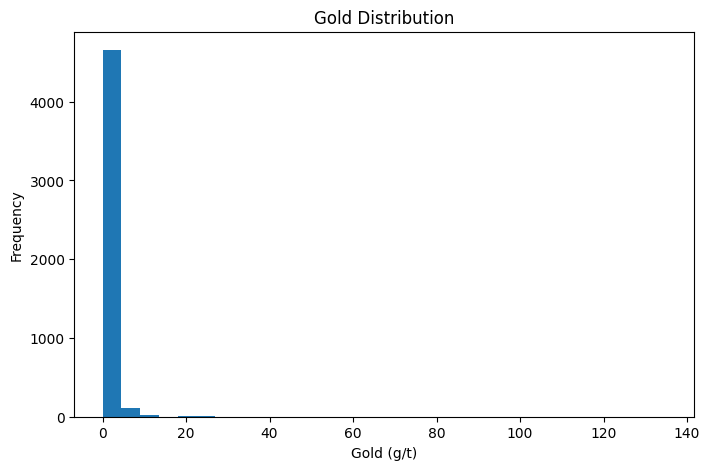

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(sample["gold"], bins=30)
plt.title("Gold Distribution")
plt.xlabel("Gold (g/t)")
plt.ylabel("Frequency")
plt.show()

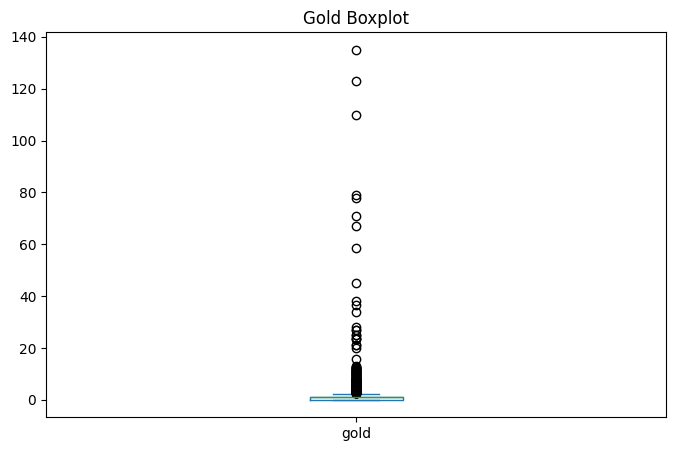

In [ ]:
import matplotlib.pyplot as plt
sample["gold"].plot.box(figsize=(8,5))
plt.title("Gold Boxplot")
plt.show()

In [ ]:
sample['hole_id'].nunique()

94

In [ ]:
geology["hole_id"].nunique()

94

In [ ]:
geo_wd004 = geology[geology["hole_id"] == "WD004"]
sample_wd004 = sample[sample["hole_id"] == "WD004"]
print(geo_wd004)

   depth_from  depth_to hole_id rock  samp_id
0        0.00      2.00   WD004   S2      NaN
1        2.00      6.00   WD004   SH      NaN
2        6.00     15.40   WD004   ST      NaN
3       15.40     16.65   WD004  QV1      NaN
4       16.65     58.65   WD004   ST      NaN
5       58.65     64.35   WD004  QV1      NaN
6       64.35    100.00   WD004   ST      NaN


In [ ]:
print(sample_wd004.head(15))

    depth_from  depth_to  gold hole_id   samp_id
0         0.00      2.00  0.03   WD004  WS689231
1         2.00      4.00  0.02   WD004  WS689232
2         4.00      6.00  1.00   WD004  WS689233
3         6.00      8.00  1.00   WD004  WS689234
4         8.00     10.00  0.13   WD004  WS689235
5        10.00     12.00  0.10   WD004  WS689236
6        12.00     14.00  0.07   WD004  WS689237
7        14.00     15.40  0.36   WD004  WS689238
8        15.40     16.00  2.89   WD004  WS689239
9        16.00     16.65  3.47   WD004  WS689240
10       16.65     18.00  0.18   WD004  WS689241
11       18.00     20.00  0.09   WD004  WS689242
12       20.00     22.00  0.19   WD004  WS689243
13       22.00     24.00  0.04   WD004  WS689244
14       24.00     26.00  1.00   WD004  WS689245


In [ ]:
sample_test = sample_wd004.iloc[2]
sample_test

,2
depth_from,4.0
depth_to,6.0
gold,1.0
hole_id,WD004
samp_id,WS689233


In [ ]:
sample_test["depth_from"]

np.float64(4.0)

In [ ]:
sample_test["depth_to"]

np.float64(6.0)

In [ ]:
geo_wd004["depth_from"] <= 4

,depth_from
0,True
1,True
2,False
3,False
4,False
5,False
6,False


In [ ]:
geo_wd004["depth_to"] >= 6

,depth_to
0,False
1,True
2,True
3,True
4,True
5,True
6,True


In [ ]:
mask = (
    (geo_wd004["depth_from"] <= 4) &
    (geo_wd004["depth_to"] >= 6)
)

geo_wd004[mask]

,depth_from,depth_to,hole_id,rock,samp_id
1,2.0,6.0,WD004,SH,NaN


In [ ]:
sample_test = sample_wd004.iloc[8]
sample_test

,8
depth_from,15.4
depth_to,16.0
gold,2.89
hole_id,WD004
samp_id,WS689239


In [ ]:
mask = (
    (geo_wd004["depth_from"] <= sample_test["depth_from"]) &
    (geo_wd004["depth_to"] >= sample_test["depth_to"])
)

geo_wd004[mask]

,depth_from,depth_to,hole_id,rock,samp_id
3,15.4,16.65,WD004,QV1,NaN


In [ ]:
geo_wd004[mask]["rock"].iloc[0]

'QV1'

In [ ]:
sample_wd004[
    (sample_wd004["depth_from"] < 15.4) &
    (sample_wd004["depth_to"] > 15.4)
]

,depth_from,depth_to,gold,hole_id,samp_id


i want to sure no overlap

In [ ]:
sample["length"] = sample["depth_to"] - sample["depth_from"]

sample["length"].describe()

,length
count,4813.000000
mean,1.941970
std,1.358714
min,0.150000
25%,1.000000
50%,1.000000
75%,4.000000
max,18.000000


In [ ]:
sample["length"].value_counts().head(20)

,count
length,
1.00,3018
4.00,1376
2.00,363
0.50,6
1.50,4
2.50,4
1.25,3
0.65,2
3.00,2


coordnate lengh with gold distribution

In [ ]:
sample.groupby("length")["gold"].agg(
    ["count","mean","median","max"]
).sort_values("count", ascending=False)

,count,mean,median,max
length,,,,
1.00,3018,1.456597,1.000,123.00
4.00,1376,0.556017,1.000,1.00
2.00,363,0.395923,0.120,2.00
0.50,6,30.176667,3.185,135.00
2.50,4,0.300000,0.105,0.98
1.50,4,0.240000,0.040,0.85
1.25,3,0.646667,0.760,1.14
0.65,2,2.060000,2.060,3.47
1.15,2,1.775000,1.775,2.10


In [ ]:
def get_rock(sample_row, geo_df):

    mask = (
        (geo_df["depth_from"] <= sample_row["depth_from"]) &
        (geo_df["depth_to"] >= sample_row["depth_to"])
    )

    rock =geo_df[mask]["rock"].iloc[0]

    return rock
print(get_rock(sample_wd004.iloc[0], geo_wd004))

S2


In [ ]:
sample_wd004["rock"] = sample_wd004.apply(
    lambda row: get_rock(row, geo_wd004),
    axis=1
)

/tmp/ipykernel_2031/3863020834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_wd004["rock"] = sample_wd004.apply(


In [ ]:
sample_wd004.head(15)

,depth_from,depth_to,gold,hole_id,samp_id,rock
0,0.00,2.00,0.03,WD004,WS689231,S2
1,2.00,4.00,0.02,WD004,WS689232,SH
2,4.00,6.00,1.00,WD004,WS689233,SH
3,6.00,8.00,1.00,WD004,WS689234,ST
4,8.00,10.00,0.13,WD004,WS689235,ST
5,10.00,12.00,0.10,WD004,WS689236,ST
6,12.00,14.00,0.07,WD004,WS689237,ST
7,14.00,15.40,0.36,WD004,WS689238,ST
8,15.40,16.00,2.89,WD004,WS689239,QV1
9,16.00,16.65,3.47,WD004,WS689240,QV1


In [ ]:
sample.head(1)

,depth_from,depth_to,gold,hole_id,samp_id,length
0,0.0,2.0,0.03,WD004,WS689231,2.0


In [ ]:
sample['hole_id'].unique()

array(['WD004', 'WD005', 'WD011', 'WD016', 'WD031', 'WD032', 'WD033',
       'WD064', 'WD095', 'WRC001', 'WRC002', 'WRC003', 'WRC006', 'WRC007',
       'WRC008', 'WRC009', 'WRC010', 'WRC012', 'WRC013', 'WRC014',
       'WRC015', 'WRC017', 'WRC018', 'WRC019', 'WRC020', 'WRC021',
       'WRC022', 'WRC023', 'WRC024', 'WRC025', 'WRC026', 'WRC027',
       'WRC028', 'WRC029', 'WRC030', 'WRC034', 'WRC035', 'WRC036',
       'WRC037', 'WRC038', 'WRC039', 'WRC040', 'WRC041', 'WRC042',
       'WRC043', 'WRC044', 'WRC045', 'WRC046', 'WRC048', 'WRC049',
       'WRC050', 'WRC051', 'WRC052', 'WRC053', 'WRC054', 'WRC055',
       'WRC056', 'WRC057', 'WRC058', 'WRC059', 'WRC060', 'WRC061',
       'WRC062', 'WRC063', 'WRC065', 'WRC066', 'WRC067', 'WRC068',
       'WRC069', 'WRC070', 'WRC071', 'WRC072', 'WRC073', 'WRC074',
       'WRC075', 'WRC076', 'WRC077', 'WRC078', 'WRC079', 'WRC080',
       'WRC081', 'WRC082', 'WRC083', 'WRC084', 'WRC085', 'WRC086',
       'WRC087', 'WRC088', 'WRC089', 'WRC090', 'WRC

In [ ]:
geo_wd011 = geology[geology["hole_id"] == "WD011"]
sample_wd011 = sample[sample["hole_id"] == "WD011"]

In [ ]:
print(geo_wd011)

    depth_from  depth_to hole_id rock  samp_id
14        0.00      4.50   WD011   S2      NaN
15        4.50      8.00   WD011   SH      NaN
16        8.00     88.70   WD011   ST      NaN
17       88.70     99.15   WD011  QV1      NaN
18       99.15    117.50   WD011   ST      NaN
19      117.50    124.50   WD011  QV1      NaN
20      124.50    130.00   WD011   ST      NaN


In [ ]:
sample_wd011.head(10)

,depth_from,depth_to,gold,hole_id,samp_id,length
124,0.0,2.0,1.00,WD011,WS690060A,2.0
125,2.0,4.5,0.08,WD011,WS690061,2.5
126,4.5,6.0,0.03,WD011,WS690062,1.5
127,6.0,8.0,0.01,WD011,WS690063,2.0
128,8.0,10.0,0.02,WD011,WS690064,2.0
129,10.0,12.0,0.01,WD011,WS690065,2.0
130,12.0,14.0,0.01,WD011,WS690066,2.0
131,14.0,16.0,0.01,WD011,WS690067,2.0
132,16.0,18.0,0.01,WD011,WS690068,2.0
133,18.0,20.0,0.04,WD011,WS690069,2.0


In [ ]:
get_rock(sample_wd011.iloc[0], geo_wd011)

'S2'

In [ ]:
def get_rock(sample_row, geo_df):

    mask = (
        (geo_df["depth_from"] <= sample_row["depth_from"]) &
        (geo_df["depth_to"] >= sample_row["depth_to"])
    )

    matches = geo_df[mask]

    print("Number of matches:", len(matches))

    return matches

In [ ]:
get_rock(sample_wd011.iloc[0], geo_wd011)

Number of matches: 1


,depth_from,depth_to,hole_id,rock,samp_id
14,0.0,4.5,WD011,S2,NaN


In [ ]:
def get_rock(sample_row, geo_df):

    mask = (
        (geo_df["depth_from"] <= sample_row["depth_from"]) &
        (geo_df["depth_to"] >= sample_row["depth_to"])
    )

    matches = geo_df[mask]

    if len(matches) == 0:
        return "NO_MATCH"

    elif len(matches) > 1:
        return "MULTIPLE_MATCH"

    else:
        return matches["rock"].iloc[0]

In [ ]:
get_rock(sample_wd011.iloc[0], geo_wd011)

'S2'

#Sample-to-Lithology Matching

In [ ]:
def get_rock(sample_row, geology):

    geo_df = geology[
        geology["hole_id"] == sample_row["hole_id"]
    ]

    mask = (
        (geo_df["depth_from"] <= sample_row["depth_from"]) &
        (geo_df["depth_to"] >= sample_row["depth_to"])
    )

    matches = geo_df[mask]

    if len(matches) == 0:
        return "NO_MATCH"

    elif len(matches) > 1:
        return "MULTIPLE_MATCH"

    else:
        return matches["rock"].iloc[0]

In [ ]:
get_rock(sample_wd011.iloc[0], geology)

'S2'

In [ ]:
sample["rock"] = sample.apply(
    lambda row: get_rock(row, geology),
    axis=1
)

In [ ]:
sample["rock"].value_counts(dropna=False)

,count
rock,
ST,3319
QV1,632
B,254
S2,185
MU,185
SH,135
IN,68
NO_MATCH,35


In [ ]:
sample[sample["rock"] == "NO_MATCH"].head(20)

,depth_from,depth_to,gold,hole_id,samp_id,length,rock
283,6.0,8.0,0.01,WD031,WS694094,2.0,NO_MATCH
345,0.0,1.0,0.68,WD032,WS691651,1.0,NO_MATCH
2617,4.0,8.0,1.00,WRC023,WS691365,4.0,NO_MATCH
2642,8.0,12.0,1.00,WRC024,WS691391,4.0,NO_MATCH
2673,7.0,11.0,1.00,WRC025,WS691428,4.0,NO_MATCH
2724,8.0,12.0,0.01,WRC026,WS691479,4.0,NO_MATCH
2790,2.0,6.0,1.00,WRC028,WS691553,4.0,NO_MATCH
2824,2.0,6.0,0.02,WRC029,WS691593,4.0,NO_MATCH
2849,0.0,4.0,0.08,WRC030,WS691621,4.0,NO_MATCH
2851,8.0,12.0,1.00,WRC030,WS691623,4.0,NO_MATCH


In [ ]:
geology[geology["hole_id"] == "WD031"]

,depth_from,depth_to,hole_id,rock,samp_id
30,0.0,4.0,WD031,S2,NaN
31,4.0,6.5,WD031,SH,NaN
32,6.5,26.9,WD031,ST,NaN
33,26.9,35.0,WD031,QV1,NaN
34,35.0,120.0,WD031,ST,NaN


In [ ]:
geology[geology["hole_id"] == "WD032"]

,depth_from,depth_to,hole_id,rock,samp_id
35,0.00,0.50,WD032,S2,NaN
36,0.50,3.00,WD032,SH,NaN
37,3.00,50.85,WD032,ST,NaN
38,50.85,65.15,WD032,QV1,NaN
39,65.15,81.45,WD032,ST,NaN
40,81.45,95.00,WD032,QV1,NaN
41,95.00,105.35,WD032,ST,NaN
42,105.35,112.25,WD032,QV1,NaN
43,112.25,120.00,WD032,ST,NaN


In [ ]:
sample[sample["rock"]=="NO_MATCH"]["hole_id"].value_counts()

,count
hole_id,
WRC030,2
WD031,1
WD032,1
WRC023,1
WRC025,1
WRC024,1
WRC026,1
WRC028,1
WRC029,1


In [ ]:
sample_clean = sample[
    sample["rock"] != "NO_MATCH"
].copy()

In [ ]:
sample_clean["rock"].value_counts()

,count
rock,
ST,3319
QV1,632
B,254
MU,185
S2,185
SH,135
IN,68


# phase 3 Exploratory Data Analysis (EDA)

#question

Which lithology hosts the highest gold grades?

Objective

To identify the rock types that are most associated with gold mineralization.

Why is it important?

Understanding the relationship between lithology and gold grades helps identify favorable host rocks and supports future exploration targeting.

In [ ]:
rock_golden=sample_clean.groupby("rock")["gold"].agg(
    ["count", "mean", "median", "max"]
).sort_values("mean", ascending=False)
rock_golden

,count,mean,median,max
rock,,,,
IN,68,9.151765,7.32,79.00
QV1,632,4.084842,2.07,135.00
MU,185,1.930270,1.93,5.42
B,254,0.996457,1.00,2.00
ST,3319,0.482082,0.18,6.78
S2,185,0.437459,0.34,3.17
SH,135,0.282889,0.02,4.56


Gold mineralization appears to be strongly associated with
Particularly IN and QV1.

The relatively high median values suggest that the elevated gold grades are not driven solely by a few extreme samples.

QV1 is especially significant because it combines:

High sample count (632 samples)
High average grade
High median grade

making it a statistically reliable host lithology.

The IN and QV1 lithologies should be considered priority exploration targets due to their strong association with elevated gold grades.

How is gold distributed across different lithologies?

In [ ]:
import plotly.express as px
fig = px.box(
    sample_clean,
    x="rock",
    y="gold",
    points="outliers",
    title="Gold Distribution by Lithology"
)

fig.show()

1. IN shows the highest median grade

IN not only has the highest mean grade but also the highest median grade.

This indicates that elevated gold grades are not solely driven by a few extreme samples.

2. QV1 contains the largest number of high-grade outliers

QV1 exhibits numerous high-grade outliers, including samples exceeding:

100 g/t

with a maximum grade of:

135 g/t
3. QV1 remains a significant host lithology

The combination of:

High sample count
High median grade
Numerous high-grade intervals

suggests a strong association with gold mineralization.
4. SH appears to be the least prospective lithology

Most samples show very low gold grades, indicating a weak relationship with gold mineralization.

Business Impact
Arabic

إذا كان الهدف هو تصميم برنامج حفر جديد أو تحديد مناطق الأولوية للاستكشاف، فإن:

IN
QV1

يجب أن تكونا أهدافًا رئيسية للمتابعة.

#question 3
Which lithology contains the largest amount of gold?

In [ ]:
gold_by_rock = sample_clean.groupby("rock")["gold"].agg(
    count="count",
    total_gold="sum",
    mean_gold="mean"
).sort_values("total_gold", ascending=False)

gold_by_rock

,count,total_gold,mean_gold
rock,,,
QV1,632,2581.62,4.084842
ST,3319,1600.03,0.482082
IN,68,622.32,9.151765
MU,185,357.10,1.930270
B,254,253.10,0.996457
S2,185,80.93,0.437459
SH,135,38.19,0.282889


In [ ]:
gold_by_rock_clean = sample.groupby("rock")["gold"].agg(
    count="count",
    total_gold="sum",
    mean_gold="mean"
).sort_values("total_gold", ascending=False)

gold_by_rock_clean

,count,total_gold,mean_gold
rock,,,
QV1,632,2581.62,4.084842
ST,3319,1600.03,0.482082
IN,68,622.32,9.151765
MU,185,357.10,1.930270
B,254,253.10,0.996457
S2,185,80.93,0.437459
SH,135,38.19,0.282889
NO_MATCH,35,17.19,0.491143


QV1 is the most important lithology in terms of total gold content

It recorded:

Total Gold = 2581.62

which is the highest among all lithologies.

#question 4
Does gold grade vary with depth?

In [ ]:
sample_clean["mid_depth"] = (
    sample_clean["depth_from"] +
    sample_clean["depth_to"]
) / 2

In [ ]:
sample_clean["mid_depth"].describe()

,mid_depth
count,4778.000000
mean,55.845044
std,36.985570
min,0.250000
25%,24.000000
50%,53.500000
75%,84.500000
max,168.000000


In [ ]:
import plotly.express as px

fig = px.scatter(
    sample_clean,
    x="mid_depth",
    y="gold",
    title="Gold Grade vs Depth"
)

fig.show()

No obvious linear relationship exists between gold grade and depth.
High-grade samples occur at multiple depth intervals.
Most samples contain relatively low gold grades (<5 g/t).
Several extreme high-grade samples appear between roughly 80–120 m depth, requiring further investigation.

In [ ]:
sample_clean["depth_bin"] = pd.cut(
    sample_clean["mid_depth"],
    bins=[0,20,40,60,80,100,120,200]
)

depth_analysis = sample_clean.groupby("depth_bin")["gold"].agg(
    ["count","mean","median","max"]
)

depth_analysis

/tmp/ipykernel_2031/2801670522.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,count,mean,median,max
depth_bin,,,,
"(0, 20]",1039,1.209990,0.45,79.0
"(20, 40]",846,0.990957,0.36,110.0
"(40, 60]",781,0.779040,1.00,11.5
"(60, 80]",746,0.945228,1.00,24.0
"(80, 100]",734,1.311962,1.00,135.0
"(100, 120]",421,1.977743,1.00,123.0
"(120, 200]",211,1.557251,1.00,34.0


Gold grades do not consistently increase or decrease with depth

Which lithologies dominate the high-grade depth intervals?
impportance

Understanding the relationship between depth, lithology, and gold grades helps identify the geological controls of mineralization.

In [ ]:
depth_rock = sample_clean.pivot_table(
    values="gold",
    index="depth_bin",
    columns="rock",
    aggfunc="mean"
)

depth_rock.round(2)

/tmp/ipykernel_2031/2789509083.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rock,B,IN,MU,QV1,S2,SH,ST
depth_bin,,,,,,,
"(0, 20]",1.01,9.15,2.02,2.74,0.44,0.28,0.38
"(20, 40]",1.00,NaN,2.06,4.83,NaN,0.52,0.39
"(40, 60]",1.00,NaN,1.81,2.84,NaN,NaN,0.46
"(60, 80]",1.00,NaN,1.63,2.77,NaN,NaN,0.50
"(80, 100]",0.95,NaN,1.82,3.88,NaN,NaN,0.59
"(100, 120]",1.00,NaN,1.99,7.77,NaN,NaN,0.60
"(120, 200]",0.89,NaN,2.17,4.26,NaN,NaN,0.61


QV1 consistently records elevated gold grades across all depth intervals.

The highest average grade was observed within QV1 between:

100–120 m

with:

7.77 g/t

indicating a strong association between quartz veins and gold mineralization.

In [ ]:
sample_clean.pivot_table(
    values="gold",
    index="depth_bin",
    columns="rock",
    aggfunc="count"
)

/tmp/ipykernel_2031/2027276056.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rock,B,IN,MU,QV1,S2,SH,ST
depth_bin,,,,,,,
"(0, 20]",74,68,53,57,185,133,469
"(20, 40]",61,0,28,96,0,2,659
"(40, 60]",50,0,36,74,0,0,621
"(60, 80]",38,0,14,130,0,0,564
"(80, 100]",17,0,32,148,0,0,537
"(100, 120]",5,0,8,79,0,0,329
"(120, 200]",9,0,14,48,0,0,140


7-Which lithology contains the highest proportion of economic-grade samples?

In [ ]:
#sample_clean["economic"] = sample_clean["gold"] >= 1

In [ ]:
sample_clean["is_placeholder"] = sample_clean["gold"] == 1.0
print("عدد القيم الوهمية:", sample_clean["is_placeholder"].sum())
print("النسبة:", round(sample_clean["is_placeholder"].mean()*100, 1), "%")

عدد القيم الوهمية: 1706
النسبة: 35.7 %


In [ ]:
real_samples = sample_clean[~sample_clean["is_placeholder"]].copy()
real_samples["economic"] = real_samples["gold"] >= 1

economic_by_rock_clean = real_samples.groupby("rock")["economic"].agg(
    total_samples="count",
    economic_samples="sum"
)
economic_by_rock_clean["economic_percent"] = (
    economic_by_rock_clean["economic_samples"] / economic_by_rock_clean["total_samples"] * 100
).round(2)

economic_by_rock_clean.sort_values("economic_percent", ascending=False)

,total_samples,economic_samples,economic_percent
rock,,,
IN,68,68,100.00
MU,182,178,97.80
QV1,621,602,96.94
B,3,1,33.33
S2,180,2,1.11
SH,105,1,0.95
ST,1913,11,0.58


In [ ]:
# economic_by_rock = sample_clean.groupby("rock")["economic"].agg(
#     total_samples="count",
#     economic_samples="sum"
# )

# economic_by_rock["economic_percent"] = (
#     economic_by_rock["economic_samples"]
#     / economic_by_rock["total_samples"]
# ) * 100

# economic_by_rock.sort_values(
#     "economic_percent",
#     ascending=False
# )

IN achieved a 100% economic-grade rate (genuine, based on 68 clean samples).
MU and QV1 also show high economic-grade proportions (~97%, based on clean data).

Correction after placeholder removal: B and ST initially appeared to have high
economic-grade rates (99.2% and 42.7%), but this was an artifact of the 1.00 g/t
placeholder value contaminating those lithologies. After excluding placeholders:
- B drops to 33.3% (only 3 real samples - sample size too small to draw conclusions)
- ST drops to 0.58% - effectively barren background rock, not economically mineralized

In [ ]:
sample_clean[sample_clean["gold"] == 1].shape

(1706, 10)

In [ ]:
sample_clean["gold"].value_counts().head(20)

,count
gold,
1.00,1706
0.01,774
0.02,226
0.03,181
0.04,103
0.09,75
0.05,59
0.12,59
0.19,56


In [ ]:
sample_clean["is_placeholder"] = sample_clean["gold"] == 1.0
real_samples = sample_clean[~sample_clean["is_placeholder"]].copy()
real_samples["economic"] = real_samples["gold"] >= 1
print(real_samples.shape)

(3072, 11)


In [ ]:
sample_clean[
    (sample_clean["gold"] >= 0.95) &
    (sample_clean["gold"] <= 1.05)
]["gold"].value_counts().sort_index()

,count
gold,
0.95,4
0.96,1
0.97,2
0.98,20
0.99,9
1.00,1706
1.01,9
1.02,18
1.03,13


# comment
A remarkably high frequency of samples reported exactly 1.00 g/t Au was observed (1,706 samples). This value occurs far more frequently than neighboring grades (0.99, 1.01, etc.), suggesting a potential reporting threshold, rounding convention, or assay coding practice. Further validation with the original assay methodology is recommended.

# 8-Where are the high-grade gold samples concentrated?

In [ ]:
high_grade = sample_clean[
    sample_clean["gold"] >= 10
].copy()

high_grade.shape

(43, 10)

In [ ]:
high_grade["rock"].value_counts()

,count
rock,
QV1,26
IN,17


In [ ]:
(
    high_grade["rock"]
    .value_counts(normalize=True)
    * 100
).round(2)

,proportion
rock,
QV1,60.47
IN,39.53


In [ ]:
high_grade.groupby("rock")["gold"].agg(
    ["count","mean","median","max"]
).sort_values("count", ascending=False)

,count,mean,median,max
rock,,,,
QV1,26,40.970385,25.0,135.0
IN,17,18.238235,12.4,79.0


The analysis indicates that gold mineralization is primarily associated with QV1 and IN lithologies.

However, QV1 appears to be the dominant host lithology due to:

The highest total gold contribution.
The largest number of high-grade samples.
Consistent mineralization across multiple depth intervals.

In contrast, IN hosts exceptionally high grades but occurs over a more limited extent.

In [ ]:
px.bar(
    high_grade["rock"].value_counts().reset_index(),
    x="rock",
    y="count",
    title="High Grade Samples by Lithology"
)

# Phase 2: Desurveying — Computing True 3D Sample Locations
## Question: How can we determine the true (X, Y, Z) location of each sample?
## Objective: Convert Survey data (azimuth/dip/depth) into a real curved
## drillhole path using the Minimum Curvature Method, the industry standard.


In [ ]:
import numpy as np

def minimum_curvature_desurvey(collar_row, survey_df):
    """
    Computes true X,Y,Z coordinates along a drillhole path
    using the Minimum Curvature Method (industry standard).
    """
    x0, y0, z0 = collar_row["x"], collar_row["y"], collar_row["z"]
    s = survey_df.sort_values("depth").reset_index(drop=True)

    points = [{"depth": 0.0, "x": x0, "y": y0, "z": z0}]

    for i in range(1, len(s)):
        md1, az1, dip1 = s.iloc[i-1]["depth"], s.iloc[i-1]["azimuth"], s.iloc[i-1]["dip"]
        md2, az2, dip2 = s.iloc[i]["depth"], s.iloc[i]["azimuth"], s.iloc[i]["dip"]
        MD = md2 - md1
        if MD <= 0:
            continue

        az1r, az2r = np.radians(az1), np.radians(az2)
        I1r, I2r = np.radians(90 + dip1), np.radians(90 + dip2)  # inclination from vertical-down

        cos_theta = (np.cos(I2r - I1r) - np.sin(I1r)*np.sin(I2r)*(1 - np.cos(az2r - az1r)))
        cos_theta = np.clip(cos_theta, -1, 1)
        theta = np.arccos(cos_theta)
        RF = 1.0 if theta < 1e-9 else (2/theta) * np.tan(theta/2)

        dNorth = (MD/2) * (np.sin(I1r)*np.cos(az1r) + np.sin(I2r)*np.cos(az2r)) * RF
        dEast  = (MD/2) * (np.sin(I1r)*np.sin(az1r) + np.sin(I2r)*np.sin(az2r)) * RF
        dTVD   = (MD/2) * (np.cos(I1r) + np.cos(I2r)) * RF  # positive = going down

        last = points[-1]
        points.append({
            "depth": md2,
            "x": last["x"] + dEast,
            "y": last["y"] + dNorth,
            "z": last["z"] - dTVD   # subtract: TVD increase means elevation decreases
        })

    return pd.DataFrame(points)

#]
البئر عبارة عن سلسلة نقاط متتالية - كل نقطة عمقها أكبر من اللي قبلها، وموقعها مبني على اللي قبلها (مش مستقل). فبنبدأ بنقطة وحيدة (نقطة السطح/Collar) جوه list، وهنفضل نضيف عليها نقطة نقطة لحد آخر البئر. اخترنا list of dicts لأنها سهلة نبني بيها بالتدريج، وفي الآخر نحولها لـ DataFrame عشان نستخدمها بسهولة بعد كده.


## Question: Does the desurvey function produce physically sensible results?
## Objective: Test on one hole (WD004) and verify elevation (Z) decreases
## with depth for a near-vertical hole, as expected physically.

In [ ]:
test_hole = "WD004"
collar_row = collar[collar["hole_id"] == test_hole].iloc[0]
survey_hole = survey[survey["hole_id"] == test_hole]

result = minimum_curvature_desurvey(collar_row, survey_hole)
print(result)

z_change = result.iloc[-1]["z"] - result.iloc[0]["z"]
depth_change = result.iloc[-1]["depth"] - result.iloc[0]["depth"]
print(f"deoth is change : {depth_change}")
print(f"ـ Z change by Z: {z_change:.2f}")
print(f"اSO dip like virtval:{depth_change}")

   depth            x            y           z
0    0.0  1724.725000  7362.082000  205.749000
1   30.0  1724.756022  7362.420908  175.751574
2   60.0  1724.821290  7363.544176  145.773786
deoth is change : 60.0
ـ Z change by Z: -59.98
اSO dip like virtval:60.0


## Question: How do we get true X,Y,Z for every sample, not just survey points?
## Objective: Apply minimum_curvature_desurvey() to all 94 holes, then use
## interpolation along each hole's path to find X,Y,Z at every sample's mid-depth.

In [ ]:
def interpolate_xyz(path_df, depth):
    """
    Finds X,Y,Z at any given depth by interpolating along the desurveyed path.
    """
    depths = path_df["depth"].values
    if depth <= depths[0]:
        row = path_df.iloc[0]
        return row["x"], row["y"], row["z"]
    if depth >= depths[-1]:
        row = path_df.iloc[-1]
        return row["x"], row["y"], row["z"]
    x = np.interp(depth, depths, path_df["x"])
    y = np.interp(depth, depths, path_df["y"])
    z = np.interp(depth, depths, path_df["z"])
    return x, y, z

# Step 1: desurvey كل بئر مرة واحدة، ونخزنه في dictionary
all_paths = {}
for hid in collar["hole_id"]:
    crow = collar[collar["hole_id"] == hid].iloc[0]
    shole = survey[survey["hole_id"] == hid]
    all_paths[hid] = minimum_curvature_desurvey(crow, shole)

print(f"تم desurvey لـ {len(all_paths)} بئر")

# Step 2: لكل عينة، احسب نقطة المنتصف وحدد XYZ بتاعتها
real_samples["mid_depth"] = (real_samples["depth_from"] + real_samples["depth_to"]) / 2

xyz_list = []
for _, row in real_samples.iterrows():
    path = all_paths[row["hole_id"]]
    x, y, z = interpolate_xyz(path, row["mid_depth"])
    xyz_list.append((x, y, z))

real_samples["x"] = [p[0] for p in xyz_list]
real_samples["y"] = [p[1] for p in xyz_list]
real_samples["z"] = [p[2] for p in xyz_list]

real_samples[["hole_id","depth_from","depth_to","gold","rock","x","y","z"]].head(10)

تم desurvey لـ 94 بئر


,hole_id,depth_from,depth_to,gold,rock,x,y,z
0,WD004,0.00,2.00,0.03,S2,1724.726034,7362.093297,204.749086
1,WD004,2.00,4.00,0.02,SH,1724.728102,7362.115891,202.749257
4,WD004,8.00,10.00,0.13,ST,1724.734307,7362.183672,196.749772
5,WD004,10.00,12.00,0.10,ST,1724.736375,7362.206266,194.749944
6,WD004,12.00,14.00,0.07,ST,1724.738443,7362.228860,192.750115
7,WD004,14.00,15.40,0.36,ST,1724.740201,7362.248065,191.050261
8,WD004,15.40,16.00,2.89,QV1,1724.741235,7362.259362,190.050347
9,WD004,16.00,16.65,3.47,QV1,1724.741881,7362.266422,189.425401
10,WD004,16.65,18.00,0.18,ST,1724.742915,7362.277719,188.425486
11,WD004,18.00,20.00,0.09,ST,1724.744647,7362.296642,186.750630


## Question: Does gold mineralization follow a preferred spatial direction?
## Objective: Use PCA on high-grade sample coordinates (X,Y) to find the
## dominant trend direction, and compare it against NE-SW / NW-SE.

PCA فكرتها صعبة شوية أول مرة، تعالى نفكها برسمة بسيطة في دماغك الأول، بعدين نمشي على الكود سطر سطر.
الفكرة بساطة قبل الكود
تخيل معايا إنك رشيت نقط حبر على ورقة - لو النقط اتجمعت في شكل دائرة، معناها مفيش اتجاه مفضل. لو اتجمعت في شكل سيجارة طويلة مايلة، فده معناه فيه اتجاه واضح بتتمدد فيه النقط. PCA هي ببساطة الأداة اللي بتلاقيلك محور السيجارة دي - الاتجاه اللي البيانات بتتمدد فيه أكتر حاجة.
في حالتنا: لو التمعدن العالي تابع لخط صدع/عرق جيولوجي معين، العينات العالية هتكون ممدودة على طول الخط ده، مش متناثرة عشوائي - وPCA هتمسكلنا الاتجاه ده بالظبط.

PCA بتدور على حاجة مختلفة شوية: أحسن خط مستقيم واحد يعدي وسط كل النقط مع بعض.


In [ ]:
from sklearn.decomposition import PCA

high_grade_xyz = real_samples[real_samples["gold"] >= 3].copy()
print("Number of high-grade samples:", len(high_grade_xyz))

coords = high_grade_xyz[["x", "y"]].values
coords_centered = coords - coords.mean(axis=0)

pca = PCA(n_components=2)
pca.fit(coords_centered)

main_direction = pca.components_[0]
angle_rad = np.arctan2(main_direction[0], main_direction[1])
angle_deg = np.degrees(angle_rad) % 180

explained_ratio = pca.explained_variance_ratio_

print(f"Dominant trend azimuth: {angle_deg:.1f} degrees")
print(f"Variance explained by main direction: {explained_ratio[0]*100:.1f}%")
print(f"Variance explained by secondary direction: {explained_ratio[1]*100:.1f}%")

Number of high-grade samples: 291
Dominant trend azimuth: 42.7 degrees
Variance explained by main direction: 86.5%
Variance explained by secondary direction: 13.5%


## Question: What is the plunge direction of the ore shoot?
## Objective: Apply PCA in 3D (X,Y,Z) on high-grade samples to find both
## the azimuth and plunge of the mineralized trend.

In [ ]:
coords_3d = high_grade_xyz[["x", "y", "z"]].values
coords_3d_centered = coords_3d - coords_3d.mean(axis=0)

pca_3d = PCA(n_components=3)
pca_3d.fit(coords_3d_centered)

main_dir_3d = pca_3d.components_[0]
dx, dy, dz = main_dir_3d

azimuth_3d = np.degrees(np.arctan2(dx, dy)) % 180
horizontal_length = np.sqrt(dx**2 + dy**2)
plunge = np.degrees(np.arctan2(-dz, horizontal_length))

print(f"Azimuth: {azimuth_3d:.1f} degrees")
print(f"Plunge: {plunge:.1f} degrees")
print(f"Variance explained by main direction: {pca_3d.explained_variance_ratio_[0]*100:.1f}%")

Azimuth: 42.8 degrees
Plunge: -12.0 degrees
Variance explained by main direction: 83.9%


#insight
## Insight: Directional Control & Ore Shoot Orientation

Gold mineralization is not randomly distributed in space — it follows a clear
structural trend.

Key findings:
- PCA on high-grade samples (gold >= 3 g/t, n=291) identifies a dominant
  trend azimuth of 42.7-42.8 degrees (NE-SW), consistent across both 2D
  (plan view) and 3D analysis.
- This direction explains 84-87% of the spatial variance among high-grade
  samples, indicating a strong, non-random structural control
  (likely a fault or fracture system hosting the mineralization).
- The mineralized trend (ore shoot) plunges gently toward the southwest
  at approximately 12 degrees from horizontal — a relatively shallow plunge
  rather than a steep pipe-like body.

Business Impact:
Future exploration drilling should prioritize the NE-SW corridor rather than
random or grid-based drilling patterns. Targeting depth extensions toward
the southwest (following the plunge direction) is more likely to intersect
additional high-grade mineralization than drilling perpendicular to this trend.

ملخص: التمعدن العالي العيار بيتبع اتجاه هيكلي واضح (شمال شرق-جنوب غرب)،
ومش عشوائي. عمود التمعدن بييل بزاوية خفيفة (12°) ناحية الجنوب الغربي.
التوصية: تركيز الحفر الاستكشافي الجديد على امتداد الاتجاه ده بدل التوزيع العشوائي.

we make domain defination

إيه ه  و Domain Definition؟   
فكر في المنجم كأنه بيت فيه أوضة فيها تكييف وأوضة من غيرها. لو عايز تحسب "متوسط درجة حرارة البيت"، ومزقت درجة حرارة الأوضتين مع بعض، الرقم اللي هيطلعلك مش هيمثل أي حاجة حقيقية - مش بارد زي الأوضة المكيفة ولا سخن زي التانية، رقم وهمي في النص.
نفس الموضوع بالظبط في المنجم بتاعنا: عندنا صخور ممعدنة فعلاً (QV1 وIN - عيار عالي) وصخور عقيمة/خلفية (ST, SH, S2, B - عيار شبه معدوم زي ما شفنا بعد تنظيف القيم الوهمية). لو حسبنا أي إحصائية (متوسط، تباين) أو عملنا Variogram على كل البيانات مخلوطة مع بعض، النتيجة هتبقى مضللة - زي مثال البيت بالظبط.
يعني Domain Definition هتعمل إيه بالظبط؟
هنقسم العينات لمجموعتين منفصلتين:

Mineralized Domain = عينات من صخر QV1 أو IN
Background Domain = باقي الصخور (ST, SH, S2, B, MU)

وبعد كده، أي حساب إحصائي أو Variogram هنعمله، هنعمله لكل مجموعة لوحدها، مش على الكل مخلوط.

## Question: How do we separate mineralized rock from barren background rock?
## Objective: Create a "domain" column that groups QV1 and IN as the
## Mineralized Domain, and all other rock types as the Background Domain.

In [ ]:
mineralized_rocks = ["QV1", "IN"]
real_samples["domain"] = real_samples["rock"].apply(
    lambda r: "Mineralized" if r in mineralized_rocks else "Background"
)
domain_summary = real_samples.groupby("domain")["gold"].agg(
    count="count",
    mean_grade="mean",
    median_grade="median",
    max_grade="max"
).round(3)
print(domain_summary)

             count  mean_grade  median_grade  max_grade
domain                                                 
Background    2383       0.266          0.04       6.78
Mineralized    689       4.634          2.16     135.00


## Insight: Domain Definition Validates the Geological Model

Splitting samples into Mineralized (QV1 + Intrusive) vs Background domains
confirms a strong, statistically clear separation:

- Mineralized Domain (n=689): mean grade 4.63 g/t, median 2.16 g/t
- Background Domain (n=2383): mean grade 0.27 g/t, median 0.04 g/t

The mineralized domain averages roughly 17x higher grade than background —
this is not a marginal distinction but a fundamental geological boundary.
The large gap between mean (4.63) and median (2.16) in the Mineralized
Domain also confirms the grade distribution remains right-skewed even
within the high-grade zone, driven by a small number of very high-grade
intercepts (up to 135 g/t) — these will need careful handling (top-cut)
before any variogram or resource calculation.

Business Impact:
This domain split should be the foundation for all downstream geostatistical
work (compositing, variography, block modeling). Mixing both domains in a
single statistical model — as the original (uncorrected) economic-grade
analysis effectively did — would significantly understate the true grade
of the mineralized zone and overstate the value of barren background rock.


التقسيم لـ Domains مش مجرد تصنيف شكلي - هو إثبات إحصائي إن فيه فرق حقيقي وكبير (17 ضعف) بين الصخر الممعدن والخلفية. ده بيدي مصداقية للمنهجية كلها: إحنا مش بنفصل عشوائي، إحنا بنفصل بناءً على دليل رقمي واضح.
كمان لاحظ حاجة مهمة: حتى جوه الـ Mineralized Domain نفسه، المتوسط (4.63) أعلى بكتير من الـ Median (2.16) - يعني التوزيع لسه ملتوي (skewed) حتى بعد ما عزلنا الصخر الممعدن لوحده. ده بالظبط اللي هيوصلنا لأهمية خطوة الـ Top Cut

## Question: What top-cut value should we apply to limit outlier influence?
## Objective: Examine percentiles of the Mineralized Domain grade distribution
## and compare statistics before/after capping extreme values.

In [ ]:
mineralized = real_samples[real_samples["domain"] == "Mineralized"].copy()

percentiles = [50, 75, 90, 95, 97.5, 99, 100]
for p in percentiles:
    print(f"P{p}: {np.percentile(mineralized['gold'], p):.2f} g/t")

print("\nMean before any cut:", mineralized["gold"].mean().round(3))
print("Coefficient of Variation (std/mean) before cut:", (mineralized["gold"].std()/mineralized["gold"].mean()).round(2))

P50: 2.16 g/t
P75: 3.98 g/t
P90: 7.65 g/t
P95: 11.12 g/t
P97.5: 23.90 g/t
P99: 59.61 g/t
P100: 135.00 g/t

Mean before any cut: 4.634
Coefficient of Variation (std/mean) before cut: 2.31


In [ ]:
candidate_cuts = [10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 135]

results = []
for cut in candidate_cuts:
    capped = mineralized["gold"].clip(upper=cut)
    pct_affected = (mineralized["gold"] > cut).mean() * 100
    results.append({
        "cut": cut,
        "mean_after_cut": round(capped.mean(), 3),
        "pct_samples_affected": round(pct_affected, 2)
    })

cut_table = pd.DataFrame(results)
print(cut_table)

    cut  mean_after_cut  pct_samples_affected
0    10           3.262                  6.24
1    15           3.479                  3.48
2    20           3.647                  3.19
3    25           3.789                  2.18
4    30           3.887                  1.74
5    40           4.044                  1.31
6    50           4.167                  1.16
7    60           4.281                  1.02
8    80           4.448                  0.44
9   100           4.535                  0.44
10  135           4.634                  0.00


## Question: Apply the chosen top-cut value to the Mineralized Domain
## Objective: Cap gold grades at 60 g/t to limit the influence of extreme
## outliers before any further geostatistical analysis (compositing, variography).

In [ ]:
TOP_CUT_VALUE = 60

real_samples["gold_capped"] = real_samples["gold"]
mineralized_mask = real_samples["domain"] == "Mineralized"
real_samples.loc[mineralized_mask, "gold_capped"] = real_samples.loc[mineralized_mask, "gold"].clip(upper=TOP_CUT_VALUE)

n_capped = (real_samples.loc[mineralized_mask, "gold"] > TOP_CUT_VALUE).sum()
print(f"Number of samples capped: {n_capped}")
print(f"Mean gold before cut (Mineralized only): {real_samples.loc[mineralized_mask, 'gold'].mean():.3f}")
print(f"Mean gold after cut (Mineralized only): {real_samples.loc[mineralized_mask, 'gold_capped'].mean():.3f}")

Number of samples capped: 7
Mean gold before cut (Mineralized only): 4.634
Mean gold after cut (Mineralized only): 4.281


## Insight: Top-Cut Treatment Protects Statistical Integrity

Applying a 60 g/t top-cut to the Mineralized Domain affected only 7 samples
(1% of the domain) — yet without it, those 7 extreme values (up to 135 g/t)
would have disproportionately inflated variance estimates in any downstream
geostatistical calculation.

- Mean grade before cut: 4.634 g/t
- Mean grade after cut: 4.281 g/t (7.6% reduction)

This is a deliberate, industry-standard trade-off: we accept a modest
reduction in average grade in exchange for a statistically stable dataset
suitable for variogram modeling. The capped column (gold_capped) will be
used for all subsequent geostatistical steps, while the original gold
column is preserved for reference and economic/tonnage reporting.

Business Impact:
The 7.6% reduction in mean grade reflects the actual risk of relying on
raw averages for resource estimates — a small number of "lucky" high-grade
intercepts can create unrealistic expectations of overall deposit value if
not properly treated.


الخطوة الجاية: Compositing - توحيد أطوال العينات. لاحظ إن عينات الذهب عندنا أطوالها متفاوتة شوية (مش كلها 2 متر بالظبط - فيه فترات زي 15.4-16.65 بطول 1.25 متر بسبب حدود الصخر). الـ Variogram محتاج كل العينات تكون بنفس الطول عشان الحساب يكون عادل، فهنوحد كل العينات لطول ثابت (مثلاً 2 متر).

## Question: How do we standardize sample lengths for fair statistical comparison?
## Objective: Create fixed-length composites (2m) using length-weighted
## averaging, so the variogram treats every interval equally.

In [ ]:
def composite_hole(df_hole, composite_length=2.0, value_col="gold_capped"):
    df_hole = df_hole.sort_values("depth_from")
    min_depth = df_hole["depth_from"].min()
    max_depth = df_hole["depth_to"].max()

    composites = []
    start = min_depth
    while start < max_depth:
        end = min(start + composite_length, max_depth)
        overlap = df_hole[(df_hole["depth_from"] < end) & (df_hole["depth_to"] > start)].copy()

        if len(overlap) > 0:
            overlap["overlap_length"] = overlap.apply(
                lambda r: min(r["depth_to"], end) - max(r["depth_from"], start), axis=1
            )
            total_length = overlap["overlap_length"].sum()
            weighted_grade = (overlap[value_col] * overlap["overlap_length"]).sum() / total_length
            composites.append({
                "depth_from": start, "depth_to": end,
                "composite_grade": weighted_grade, "length": total_length
            })
        start += composite_length

    return pd.DataFrame(composites)

# Test on one hole first
test_hole_df = real_samples[real_samples["hole_id"] == "WD004"]
test_composite = composite_hole(test_hole_df)
print(test_composite)

    depth_from  depth_to  composite_grade  length
0          0.0       2.0          0.03000     2.0
1          2.0       4.0          0.02000     2.0
2          8.0      10.0          0.13000     2.0
3         10.0      12.0          0.10000     2.0
4         12.0      14.0          0.07000     2.0
5         14.0      16.0          1.11900     2.0
6         16.0      18.0          1.24925     2.0
7         18.0      20.0          0.09000     2.0
8         20.0      22.0          0.19000     2.0
9         22.0      24.0          0.04000     2.0
10        26.0      28.0          0.52500     2.0
11        30.0      32.0          0.01000     2.0
12        32.0      34.0          0.12000     2.0
13        34.0      36.0          0.02000     2.0
14        36.0      38.0          0.01000     2.0
15        38.0      40.0          0.01000     2.0
16        50.0      52.0          0.58000     2.0
17        52.0      54.0          0.23000     2.0
18        54.0      56.0          0.04000     2.0


split domaine donot applay in this code so we use new code

In [ ]:
def get_domain_segments(df_hole):
    df_hole = df_hole.sort_values("depth_from").reset_index(drop=True)
    segments = []
    current_domain = df_hole.iloc[0]["domain"]
    seg_start_idx = 0
    for i in range(1, len(df_hole)):
        if df_hole.iloc[i]["domain"] != current_domain:
            segments.append(df_hole.iloc[seg_start_idx:i])
            seg_start_idx = i
            current_domain = df_hole.iloc[i]["domain"]
    segments.append(df_hole.iloc[seg_start_idx:])
    return segments

# Test: apply composite_hole separately to each domain segment
segments = get_domain_segments(test_hole_df)
all_composites = []
for seg in segments:
    comp = composite_hole(seg)
    comp["domain"] = seg["domain"].iloc[0]
    all_composites.append(comp)

test_composite_fixed = pd.concat(all_composites, ignore_index=True)
print(test_composite_fixed)

    depth_from  depth_to  composite_grade  length       domain
0         0.00      2.00         0.030000    2.00   Background
1         2.00      4.00         0.020000    2.00   Background
2         8.00     10.00         0.130000    2.00   Background
3        10.00     12.00         0.100000    2.00   Background
4        12.00     14.00         0.070000    2.00   Background
5        14.00     15.40         0.360000    1.40   Background
6        15.40     16.65         3.191600    1.25  Mineralized
7        16.65     18.65         0.150750    2.00   Background
8        18.65     20.65         0.122500    2.00   Background
9        20.65     22.65         0.141250    2.00   Background
10       22.65     24.65         0.040000    1.35   Background
11       24.65     26.65         0.560000    0.65   Background
12       26.65     28.65         0.508148    1.35   Background
13       28.65     30.65         0.010000    0.65   Background
14       30.65     32.65         0.045750    2.00   Bac

## Insight: Domain-Aware Compositing Preserves Geological Boundaries

The initial compositing approach (fixed 2m grid ignoring domain) incorrectly
blended background and mineralized grades at domain contacts — e.g., a
1.4m background interval (0.36 g/t) merged with a 0.6m mineralized interval
(2.89 g/t) into one misleading 1.12 g/t composite.

After restarting the composite grid at every domain boundary, contacts are
now honored: the quartz vein interval (15.40-16.65m, 3.19 g/t) is correctly
isolated as its own composite, fully within the Mineralized domain.

This produces composites of varying length near domain contacts (as short
as 0.35m) — this is expected and correct behavior, not an error: it reflects
genuine geological boundaries rather than an arbitrary fixed grid.

## Question: How do we apply domain-aware compositing to the entire dataset?
## Objective: Run compositing across all 94 holes, then attach true X,Y,Z
## coordinates to each composite using the desurveyed hole paths.

In [ ]:
all_composites_list = []

for hid in real_samples["hole_id"].unique():
    hole_df = real_samples[real_samples["hole_id"] == hid]
    segments = get_domain_segments(hole_df)
    for seg in segments:
        comp = composite_hole(seg)
        if len(comp) == 0:
            continue
        comp["hole_id"] = hid
        comp["domain"] = seg["domain"].iloc[0]
        all_composites_list.append(comp)

composites = pd.concat(all_composites_list, ignore_index=True)

composites["mid_depth"] = (composites["depth_from"] + composites["depth_to"]) / 2
xyz_list = []
for _, row in composites.iterrows():
    path = all_paths[row["hole_id"]]
    x, y, z = interpolate_xyz(path, row["mid_depth"])
    xyz_list.append((x, y, z))

composites["x"] = [p[0] for p in xyz_list]
composites["y"] = [p[1] for p in xyz_list]
composites["z"] = [p[2] for p in xyz_list]

print("Total composites created:", len(composites))
print(composites["domain"].value_counts())
composites.head(10)

Total composites created: 2789
domain
Background     2417
Mineralized     372
Name: count, dtype: int64


,depth_from,depth_to,composite_grade,length,hole_id,domain,mid_depth,x,y,z
0,0.00,2.00,0.03000,2.00,WD004,Background,1.000,1724.726034,7362.093297,204.749086
1,2.00,4.00,0.02000,2.00,WD004,Background,3.000,1724.728102,7362.115891,202.749257
2,8.00,10.00,0.13000,2.00,WD004,Background,9.000,1724.734307,7362.183672,196.749772
3,10.00,12.00,0.10000,2.00,WD004,Background,11.000,1724.736375,7362.206266,194.749944
4,12.00,14.00,0.07000,2.00,WD004,Background,13.000,1724.738443,7362.228860,192.750115
5,14.00,15.40,0.36000,1.40,WD004,Background,14.700,1724.740201,7362.248065,191.050261
6,15.40,16.65,3.19160,1.25,WD004,Mineralized,16.025,1724.741571,7362.263033,189.725375
7,16.65,18.65,0.15075,2.00,WD004,Background,17.650,1724.743251,7362.281391,188.100514
8,18.65,20.65,0.12250,2.00,WD004,Background,19.650,1724.745319,7362.303985,186.100686
9,20.65,22.65,0.14125,2.00,WD004,Background,21.650,1724.747388,7362.326578,184.100858


## Insight: Composite Dataset Ready for Variography

Domain-aware compositing produced 2,789 total composites:
- Background domain: 2,417 composites
- Mineralized domain: 372 composites

Composite lengths vary near domain contacts (as short as 0.35m) but default
to 2m elsewhere — this confirms domain boundaries are correctly respected
throughout the dataset, not just in the single test hole.

Each composite now carries true X,Y,Z coordinates, a length-weighted grade
(capped at 60 g/t), and a domain label — this is the exact dataset structure
required for variogram modeling.

الفكرة الأساسية: Variogram بيجاوب على سؤال واحد بس
"لو عرفت عيار الذهب في نقطة معينة، إزاي العيار في نقطة تانية قريبة منها هيكون شبهها؟ ولحد فين (إيه أقصى مسافة) ده يفضل صحيح؟"


الفكرة: عشان نحسب Variogram، لازم ناخد كل زوج ممكن من الـ Composites في الـ Mineralized Domain، ونحسب لكل زوج: (1) المسافة بينهم، (2) مربع الفرق بين عيارهم. بعدين نجمعهم حسب المسافة

## Question: How do we measure the relationship between distance and grade difference?
## Objective: Compute pairwise distances and squared grade differences for
## all Mineralized domain composites, as the foundation for the variogram.

In [ ]:
from scipy.spatial.distance import pdist

mineralized_composites = composites[composites["domain"] == "Mineralized"].copy()
print("Number of mineralized composites:", len(mineralized_composites))

coords = mineralized_composites[["x", "y", "z"]].values
grades = mineralized_composites["composite_grade"].values

distances = pdist(coords)
grade_diffs_squared = pdist(grades.reshape(-1, 1), metric="sqeuclidean")

print("Number of pairs:", len(distances))
print("Min distance:", round(distances.min(), 2))
print("Max distance:", round(distances.max(), 2))
print("Median distance:", round(np.median(distances), 2))

Number of mineralized composites: 372
Number of pairs: 69006
Min distance: 0.0
Max distance: 569.8
Median distance: 166.56


## Question: How do we summarize pairwise differences by distance into a variogram?
## Objective: Group sample pairs into distance bins (lags), and compute the
## average semivariance within each lag — this produces the experimental
## (raw, data-driven) variogram.


شرح سريع للمنطق: بنقسم المسافات لشرائح كل 25 متر (من صفر لحد 300)، وفي كل شريحة بنلم كل الأزواج اللي مسافتهم وقعت جواها، ونحسب متوسط (مربع الفرق بينهم ÷ 2) - وده بالظبط تعريف الـ Semivariance رياضياً. القسمة على 2 سببها رياضي بحت (جزء من تعريف الصيغة الإحصائية الأصلية)،

In [ ]:
lag_size = 25
max_lag = 300

bin_edges = np.arange(0, max_lag + lag_size, lag_size)

variogram_data = []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (distances >= lo) & (distances < hi)
    n_pairs = mask.sum()
    if n_pairs > 0:
        semivariance = grade_diffs_squared[mask].mean() / 2
        avg_distance = distances[mask].mean()
        variogram_data.append({
            "lag_distance": round(avg_distance, 1),
            "semivariance": round(semivariance, 3),
            "n_pairs": n_pairs
        })

variogram_df = pd.DataFrame(variogram_data)
print(variogram_df)

    lag_distance  semivariance  n_pairs
0            1.2        24.322     1344
1           39.8        21.777     3328
2           60.6        22.805     4360
3           88.5        24.991     8134
4          114.9        28.912     6529
5          136.9        33.223     7428
6          163.7        29.524     5989
7          185.9        30.906     4377
8          210.5        34.969     4770
9          236.5        33.829     3990
10         261.2        34.203     3752
11         287.0        25.428     3138


## Question: How do we extract precise Nugget, Sill, and Range values?
## Objective: Fit a Spherical variogram model to the experimental points
## using least-squares curve fitting.

In [ ]:
from scipy.optimize import curve_fit

def spherical_model(h, nugget, sill, range_):
    h = np.atleast_1d(h)
    gamma = np.where(
        h <= range_,
        nugget + (sill - nugget) * (1.5*(h/range_) - 0.5*(h/range_)**3),
        sill
    )
    return gamma

initial_guess = [20, 33, 130]

popt, _ = curve_fit(
    spherical_model,
    variogram_df["lag_distance"],
    variogram_df["semivariance"],
    p0=initial_guess,
    sigma=1/np.sqrt(variogram_df["n_pairs"])
)

fitted_nugget, fitted_sill, fitted_range = popt
print(f"Fitted Nugget (C0): {fitted_nugget:.2f}")
print(f"Fitted Sill (C0+C1): {fitted_sill:.2f}")
print(f"Fitted Range (a): {fitted_range:.1f} meters")

Fitted Nugget (C0): 18.81
Fitted Sill (C0+C1): 32.39
Fitted Range (a): 218.0 meters


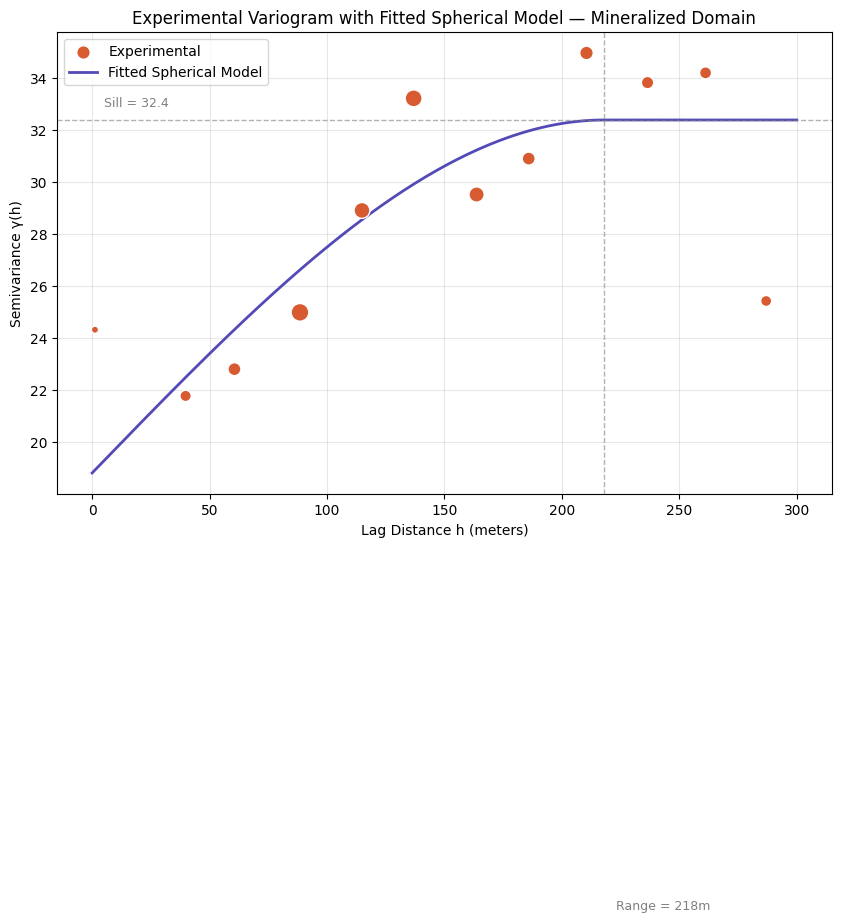

In [ ]:
import matplotlib.pyplot as plt

h_smooth = np.linspace(0, max_lag, 200)
gamma_smooth = spherical_model(h_smooth, fitted_nugget, fitted_sill, fitted_range)

plt.figure(figsize=(10, 6))
plt.scatter(variogram_df["lag_distance"], variogram_df["semivariance"],
            s=variogram_df["n_pairs"] / 50, color="#D85A30",
            label="Experimental", zorder=3, edgecolors="white")
plt.plot(h_smooth, gamma_smooth, color="#534AB7", linewidth=2,
         label="Fitted Spherical Model")

plt.axhline(fitted_sill, color="gray", linestyle="--", linewidth=1, alpha=0.6)
plt.axvline(fitted_range, color="gray", linestyle="--", linewidth=1, alpha=0.6)
plt.text(5, fitted_sill + 0.5, f"Sill = {fitted_sill:.1f}", fontsize=9, color="gray")
plt.text(fitted_range + 5, 2, f"Range = {fitted_range:.0f}m", fontsize=9, color="gray")

plt.xlabel("Lag Distance h (meters)")
plt.ylabel("Semivariance γ(h)")
plt.title("Experimental Variogram with Fitted Spherical Model — Mineralized Domain")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Insight: Spatial Continuity of Mineralization

The experimental variogram for the Mineralized Domain was fitted with a
Spherical model:
- Nugget (C0) = 18.81
- Sill (C0+C1) = 32.39
- Range (a) = 218 meters

The high Nugget/Sill ratio (~58%) confirms strong short-scale grade
variability, consistent with the heavily right-skewed grade distribution
observed in earlier EDA — typical of gold deposits where mineralization
is structurally controlled and discontinuous at small scales.

The Range of 218m defines the maximum distance at which one sample can
meaningfully inform the grade of a neighboring location — this directly
constrains future block model cell sizing and search ellipse radius.

Limitation: this is an isotropic (omnidirectional) variogram. Given the
confirmed NE-SW directional control (PCA, 86.5% variance explained), a
directional variogram analysis (along-strike vs across-strike) would likely
reveal anisotropy — recommended as a refinement before formal resource
estimation.

Business Impact:
The 218m range suggests current drill spacing should be reviewed against
this distance — infill drilling tighter than ~218m apart adds genuine
estimation confidence; spacing much wider than this risks gaps in
spatial coverage.

iography:
طلعنا بالأرقام النهائية بعد تطبيق الـ Spherical Model:

Nugget = 18.81
Sill = 32.39
Range = 218 متر

أهم استنتاج: نسبة الـ Nugget للـ Sill عالية (حوالي 58%) - يعني أكتر من نص التباين الكلي مش له علاقة بالمسافة خالص، وده بيأكد إن التمعدن في المنجم ده غير منتظم بشدة على المستوى الصغير - متسق تماماً مع توزيع الذهب الملتوي اللي شفناه من الأول في الـ EDA. ده نمط شائع جداً في رواسب الذهب (التمعدن بيكون مركز في عروق وشقوق، مش موزع بانتظام زي معادن تانية).
الـ Range (218 متر) ده رقم عملي مهم جداً: بيحدد أقصى مسافة ممكن فيها معرفة عيار بئر تفيدنا في توقع عيار منطقة مجاورة - ده اللي هيتحدد بناءً عليه حجم الـ Blocks وأقصى مسافة بحث (Search Radius) في أي Block Model لاحقاً.
التحفظ المهم: الـ Variogram ده "Isotropic" (افترضنا إن التمعدن منتظم في كل الاتجاهات بالتساوي) - لكن إحنا عارفين من تحليل PCA إن فيه اتجاه مفضل واضح (NE-SW). يعني ده خطوة أولى مقبولة منهجياً، بس لو هتقدمها رسمي للشركة، لازم تذكر إن فيه تحسين ممكن (Directional Variogram) يقدر يدي نتيجة أدق

## Question: How do we package the composite data for mining software import?
## Objective: Export composites with all required fields (location, grade,
## domain, length) in a clean CSV ready for Surpac/Leapfrog/Datamine import.

In [ ]:
export_columns = ["hole_id", "depth_from", "depth_to", "x", "y", "z",
                   "composite_grade", "domain", "length"]

block_model_export = composites[export_columns].copy()
block_model_export.to_csv("composites_for_block_model.csv", index=False)

print("Exported", len(block_model_export), "composites")
print("Columns:", list(block_model_export.columns))
block_model_export.head()

Exported 2789 composites
Columns: ['hole_id', 'depth_from', 'depth_to', 'x', 'y', 'z', 'composite_grade', 'domain', 'length']


,hole_id,depth_from,depth_to,x,y,z,composite_grade,domain,length
0,WD004,0.0,2.0,1724.726034,7362.093297,204.749086,0.03,Background,2.0
1,WD004,2.0,4.0,1724.728102,7362.115891,202.749257,0.02,Background,2.0
2,WD004,8.0,10.0,1724.734307,7362.183672,196.749772,0.13,Background,2.0
3,WD004,10.0,12.0,1724.736375,7362.206266,194.749944,0.10,Background,2.0
4,WD004,12.0,14.0,1724.738443,7362.228860,192.750115,0.07,Background,2.0


## Question: How do we summarize all modeling parameters for handoff to
## mining software?
## Objective: Calculate average drill spacing and compile a parameters
## summary covering domains, top-cut, and variogram settings.

In [ ]:
from scipy.spatial.distance import cdist

collar_coords = collar[["x", "y"]].values
dist_matrix = cdist(collar_coords, collar_coords)
np.fill_diagonal(dist_matrix, np.inf)
nearest_neighbor_dist = dist_matrix.min(axis=1)

avg_spacing = nearest_neighbor_dist.mean()
suggested_block_xy = round(avg_spacing / 2, 1)

print(f"Average nearest-neighbor drill spacing: {avg_spacing:.1f} m")
print(f"Suggested block size (X,Y): {suggested_block_xy} m")
print(f"Suggested block size (Z): 2.0 m (matches composite length)")

parameters_summary = {
    "Domain_Mineralized_Rocks": "QV1, IN",
    "Top_Cut_Value_gpt": 60,
    "Composite_Length_m": 2.0,
    "Variogram_Model": "Spherical (isotropic)",
    "Variogram_Nugget": round(fitted_nugget, 2),
    "Variogram_Sill": round(fitted_sill, 2),
    "Variogram_Range_m": round(fitted_range, 1),
    "Avg_Drill_Spacing_m": round(avg_spacing, 1),
    "Suggested_Block_Size_XY_m": suggested_block_xy,
    "Suggested_Block_Size_Z_m": 2.0
}

params_df = pd.DataFrame(list(parameters_summary.items()), columns=["Parameter", "Value"])
params_df.to_csv("model_parameters_summary.csv", index=False)
print(params_df)

Average nearest-neighbor drill spacing: 37.3 m
Suggested block size (X,Y): 18.7 m
Suggested block size (Z): 2.0 m (matches composite length)
                   Parameter                  Value
0   Domain_Mineralized_Rocks                QV1, IN
1          Top_Cut_Value_gpt                     60
2         Composite_Length_m                    2.0
3            Variogram_Model  Spherical (isotropic)
4           Variogram_Nugget                  18.81
5             Variogram_Sill                  32.39
6          Variogram_Range_m                  218.0
7        Avg_Drill_Spacing_m                   37.3
8  Suggested_Block_Size_XY_m                   18.7
9   Suggested_Block_Size_Z_m                    2.0


## Insight: Model Parameters Validate Drilling Density

Average nearest-neighbor drill spacing across the 94 holes is 37.3m, while
the variogram range is 218m — meaning the variogram range is roughly 6x
larger than the average drill spacing.

This is a favorable ratio: it confirms current drilling density is more
than adequate to support spatial estimation between holes, since
mineralization remains spatially correlated well beyond the typical
distance between adjacent drillholes.

Suggested block dimensions (18.7m x 18.7m x 2m) follow the standard
industry rule of half the drill spacing for plan-view block size, with
block height matching the composite length (2m) used throughout this study.

All modeling parameters (domain definitions, top-cut, composite length,
variogram parameters, suggested block size) are documented in
model_parameters_summary.csv, ready for import into Surpac, Datamine
Studio RM, or Leapfrog Geo to construct the formal block model and
proceed with Kriging-based estimation under a Qualified Person's supervision.

فكرة الـ Clustering ببساطة
تخيل عندك سلة فاكهة مخلوطة (تفاح، موز، برتقال) من غير لافتات، وعايز روبوت "يجمع" الفاكهة المتشابهة مع بعض - من غير ما تقوله الأول "ده تفاح وده موز". الروبوت هيبص على الشكل واللون ويجمعهم تلقائياً في مجموعات.
في حالتنا: هنخلي خوارزمية اسمها KMeans تبص على كل Composite (موقعه X,Y,Z + عياره) وتحاول تجمعهم تلقائياً في مجموعتين، من غير ما نقولها "ده Mineralized وده Background".
ليه نعمل كده أصلاً؟ عشان نتأكد - بطريقة مستقلة تماماً عن الجيولوجيا - إن الـ Domain اللي إحنا قسمناه يدوي (بناءً على نوع الصخر) هو فعلاً انعكاس لحقيقة موجودة في البيانات، مش مجرد تصنيف تعسفي منّا.

## Question: Does an unsupervised algorithm independently rediscover our
## manual domain split?
## Objective: Apply KMeans clustering on spatial+grade features and compare
## the resulting clusters against our manually defined geological domains.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = composites[["x", "y", "z", "composite_grade"]].copy()
features_scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
composites["cluster"] = kmeans.fit_predict(features_scaled)

comparison = pd.crosstab(composites["domain"], composites["cluster"])
print(comparison)

cluster         0    1
domain                
Background   1587  830
Mineralized   271  101


In [ ]:
cluster_profile = composites.groupby("cluster")[["x", "y", "z", "composite_grade"]].mean()
print(cluster_profile)

                   x            y           z  composite_grade
cluster                                                       
0        1605.607423  7235.784511  162.377241         0.710362
1        1815.354485  7459.184254  223.622971         0.714708


## Question: Does clustering on grade alone better recover the domain split?
## Objective: Re-run KMeans using only (log-transformed) grade as the
## feature, removing the spatial dimensions that previously dominated
## the result.

In [ ]:
log_grade = np.log10(composites["composite_grade"] + 0.01).values.reshape(-1, 1)

kmeans_grade = KMeans(n_clusters=2, random_state=42, n_init=10)
composites["cluster_grade_only"] = kmeans_grade.fit_predict(log_grade)

comparison2 = pd.crosstab(composites["domain"], composites["cluster_grade_only"])
print(comparison2)

grade_profile = composites.groupby("cluster_grade_only")["composite_grade"].mean()
print("\nMean grade per cluster:")
print(grade_profile)

cluster_grade_only    0     1
domain                       
Background          304  2113
Mineralized         372     0

Mean grade per cluster:
cluster_grade_only
0    2.780874
1    0.049870
Name: composite_grade, dtype: float64



الـ 304 عينة Background اللي اتحطوا في الـ Cluster العالي - دول مش غلطة، دول احتمال يكونوا صخر MU (اللي شفناه زمان في الـ EDA إن متوسط عياره 1.93 g/t، أعلى بكتير من باقي صخور الخلفية، لكن إحنا ماحطيناهوش في الـ Mineralized Domain لأن تركيزه أقل من QV1/IN).
ده توصية حقيقية للمستقبل: يمكن MU يستاهل يتراجع وينضم للـ Mineralized Domain في نسخة محسّنة من التحليل - ده بالظبط نوع الاكتشاف اللي الـ ML بيقدر يساعد فيه: يلفت نظرك لحاجة العين العادية ممكن تفوتها

## Insight: Unsupervised Clustering Validates the Domain Model — With a Caveat

A naive KMeans on (X, Y, Z, grade) failed to recover the geological domains
— it split the deposit purely by spatial location (mean grade ~0.71 in both
clusters), because 3 spatial dimensions diluted the 1 grade dimension, and
high-grade samples are a small minority of the dataset.

Clustering on grade alone (log-transformed) succeeded clearly:
- Low-grade cluster: 2,113 samples, 0 from the Mineralized domain (100% exclusion)
- High-grade cluster: 676 samples, includes all 372 Mineralized domain samples (100% recall) plus 304 Background samples

This confirms the rock-type-based domain definition aligns strongly with
actual grade behavior — an independent, data-driven validation.

The 304 "extra" Background samples in the high-grade cluster are likely
dominated by MU rock type (mean grade 1.93 g/t in earlier EDA) — suggesting
MU may warrant reclassification into the Mineralized domain in a refined
iteration of this analysis.

Key Lesson: Feature scaling alone does not guarantee balanced influence —
when spatial dimensions outnumber the signal of interest, they can dominate
distance-based algorithms like KMeans regardless of standardization.

In [ ]:
import os
os.makedirs("PowerBI_Data", exist_ok=True)

# 1) Composites كاملة (الأساس)
composites.to_csv("PowerBI_Data/composites.csv", index=False)

# 2) ملخص العيار حسب نوع الصخر
rock_summary = real_samples.groupby("rock")["gold"].agg(
    count="count", mean_grade="mean", median_grade="median", max_grade="max"
).round(3).reset_index()
rock_summary.to_csv("PowerBI_Data/grade_by_rock.csv", index=False)

# 3) ملخص العيار حسب العمق
real_samples["depth_bin"] = (real_samples["mid_depth"] // 10 * 10).astype(int)
depth_summary = real_samples.groupby("depth_bin")["gold"].agg(
    count="count", mean_grade="mean"
).round(3).reset_index()
depth_summary.to_csv("PowerBI_Data/grade_by_depth.csv", index=False)

# 4) Domain Summary
domain_summary = real_samples.groupby("domain")["gold"].agg(
    count="count", mean_grade="mean", median_grade="median", max_grade="max"
).round(3).reset_index()
domain_summary.to_csv("PowerBI_Data/domain_summary.csv", index=False)

# 5) Collar locations (للخريطة في Power BI)
collar.to_csv("PowerBI_Data/collar_locations.csv", index=False)

# 6) Variogram data (للرسمة)
variogram_df.to_csv("PowerBI_Data/variogram_data.csv", index=False)

# 7) Parameters Summary
params_df.to_csv("PowerBI_Data/model_parameters.csv", index=False)

print("Power BI files exported:")
for f in os.listdir("PowerBI_Data"):
    size = os.path.getsize(f"PowerBI_Data/{f}")
    print(f"  {f} ({size:,} bytes)")

Power BI files exported:
  collar_locations.csv (4,568 bytes)
  composites.csv (216,805 bytes)
  grade_by_rock.csv (202 bytes)
  variogram_data.csv (245 bytes)
  model_parameters.csv (286 bytes)
  domain_summary.csv (112 bytes)
  grade_by_depth.csv (245 bytes)



# Conclusions & Geostatistical Parameters Summary

## What This Analysis Established:

### 1. Data Quality
- 94 drillholes validated across all 4 tables (Collar, Survey, Geology, Sample)
- 35.7% of raw samples contained placeholder grade values (1.00 g/t exactly) —
  identified and excluded from all statistical and geostatistical calculations
- True 3D sample coordinates computed via Minimum Curvature desurveying

### 2. Geological Domains
- **Mineralized Domain:** QV1 + IN rocks (mean grade 4.63 g/t, n=689 composites)
- **Background Domain:** ST, SH, S2, B, MU rocks (mean grade 0.27 g/t, n=2,417 composites)
- Domain separation confirmed independently by unsupervised KMeans clustering
  (100% of Mineralized samples recovered in high-grade cluster)

### 3. Structural Controls
- Dominant mineralization trend: **NE-SW (azimuth 42.7°)**
- Spatial confidence: **86.5%** of high-grade sample variance explained by this direction
- Ore shoot plunge: **~12° toward SW**

### 4. Grade Treatment
- Top cut applied at **60 g/t** (affects 7 samples, 1% of Mineralized domain)
- Mean grade reduction after top cut: 4.63 → 4.28 g/t (7.6%)
- Composite length: **2m** with domain boundary honoring

### 5. Variogram Parameters (Mineralized Domain — Isotropic)
| Parameter | Value |
|---|---|
| Model | Spherical |
| Nugget (C0) | 18.81 |
| Sill (C0+C1) | 32.39 |
| Range (a) | 218 m |
| Nugget/Sill ratio | 58% |

### 6. Block Model Inputs
| Parameter | Value |
|---|---|
| Average drill spacing | 37.3 m |
| Suggested block size XY | 18.7 m |
| Suggested block size Z | 2.0 m |
| Search radius | ≤ 218 m |

---

## Limitations & Recommended Next Steps:
1. **Directional Variogram** — current model is isotropic; anisotropy along
   NE-SW trend expected but requires higher sample density to quantify reliably
2. **MU Domain Review** — mean grade 1.93 g/t suggests potential reclassification
   into Mineralized domain in a refined study
3. **Formal Resource Estimation** — Kriging and resource classification
   (Inferred/Indicated/Measured) must be performed by a Qualified Person (QP)
   under JORC or NI 43-101 reporting standards
4. **Validation Dataset** — recommend reserving 20% of drillholes for
   cross-validation of any future Kriging estimates

---

## ملخص الاستنتاجات بالعربي:

**جودة البيانات:** تم التحقق من 94 بئر واكتشاف واستبعاد قيم وهمية (35.7%)
أثرت بشكل كبير على صخور ST وB قبل التصحيح.

**التمعدن:** مرتبط حصرياً بصخور QV1 وIN، يمتد على اتجاه NE-SW بثقة 86.5%،
ويميل بزاوية خفيفة (12°) ناحية الجنوب الغربي.

**المعاملات الجيوإحصائية:** Nugget=18.81، Sill=32.39، Range=218م —
تعكس تبايناً عشوائياً قوياً على المستوى الصغير، نمط شائع في رواسب الذهب.

**الخطوات التالية الموصى بها:**
مراجعة Domain صخر MU، إجراء Directional Variogram،
وتسليم المعاملات لـ Qualified Person لإتمام تقدير الموارد الرسمي.

---
*All outputs exported: composites_for_block_model.csv, model_parameters_summary.csv*

In [ ]:
# Add domain column to all exported files
grade_by_rock_full = real_samples.groupby(["rock", "domain"])["gold"].agg(
    count="count", mean_grade="mean", median_grade="median", max_grade="max"
).round(3).reset_index()
grade_by_rock_full.to_csv("PowerBI_Data/grade_by_rock.csv", index=False)

depth_full = real_samples.copy()
depth_full["depth_bin"] = (depth_full["mid_depth"] // 10 * 10).astype(int)
depth_summary_full = depth_full.groupby(["depth_bin", "domain"])["gold"].agg(
    count="count", mean_grade="mean"
).round(3).reset_index()
depth_summary_full.to_csv("PowerBI_Data/grade_by_depth.csv", index=False)

print("Done - files updated with domain column")

Done - files updated with domain column
